# Relación entre Fulfilment y estado de los pedidos

En este notebook analizo si los pedidos gestionados por Amazon y los gestionados por Merchant presentan diferencias en sus estados. El objetivo es explorar si el método de gestión está relacionado con diferentes resultados de los pedidos.

In [3]:
from pathlib import Path
import pandas as pd

rutas_dataset = [
    Path('../data/Amazon_Sales.csv'),
    Path('data/Amazon_Sales.csv')
]

ruta_dataset = next((ruta for ruta in rutas_dataset if ruta.exists()), None)

if ruta_dataset is None:
    raise FileNotFoundError('No se encontró data/Amazon_Sales.csv')

df = pd.read_csv(ruta_dataset)

print("Dataset cargado correctamente.")
print("Filas y columnas:", df.shape)

Dataset cargado correctamente.
Filas y columnas: (128975, 22)


In [4]:
print('Valores únicos de Fulfilment:')
print(df['Fulfilment'].value_counts(dropna=False))

print('\nValores únicos de Status:')
print(df['Status'].value_counts(dropna=False))

print('\nPedidos por Fulfilment y Status:')
print(pd.crosstab(df['Fulfilment'], df['Status'], dropna=False))

Valores únicos de Fulfilment:
Fulfilment
Amazon      89698
Merchant    39277
Name: count, dtype: int64

Valores únicos de Status:
Status
Shipped                          77804
Shipped - Delivered to Buyer     28769
Cancelled                        18332
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

Pedidos por Fulfilment y Status:
Status      Cancelled  Pending  Pending - Waiting for Pick Up  Shipped  \
Fulfilment                                                               
Amazon          11471      415                              0    77804   
Merchant         6861      243                            281        0   


Porcentaje de pedidos por estado agrupado dentro de cada Fulfilment:


Status agrupado,Cancelled,Otros estados,Pending (incl. substatus),Shipped (incl. substatus)
Fulfilment,,,,
Amazon,12.79,0.01,0.46,86.74
Merchant,17.47,0.00,1.33,81.20


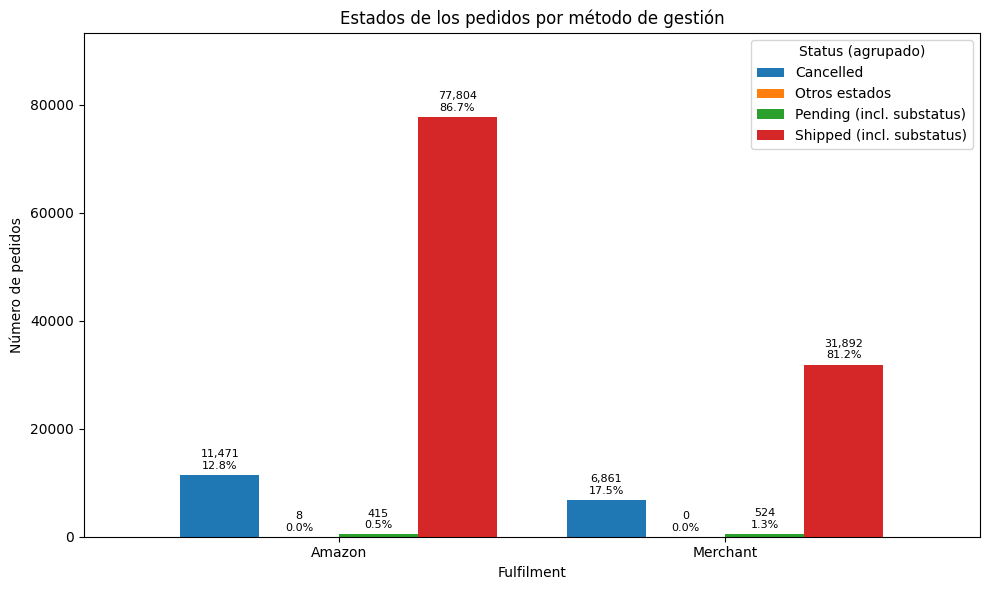

Interpretación: los patrones no son idénticos. Amazon tiene 5.5 puntos porcentuales más de pedidos en 'Shipped (incl. substatus)', mientras que Merchant tiene 4.7 puntos porcentuales más de pedidos cancelados. La comparación es descriptiva y no implica que el método de gestión cause esos resultados.


In [ ]:
3import matplotlib.pyplot as plt

analisis = df[['Fulfilment', 'Status']].copy()
estado = analisis['Status'].astype('string').fillna('')
analisis['Status agrupado'] = estado.map(
    lambda valor: 'Shipped (incl. substatus)' if valor.startswith('Shipped')
    else 'Pending (incl. substatus)' if valor.startswith('Pending')
    else 'Cancelled' if valor == 'Cancelled'
    else 'Otros estados'
)

fulfilment_observados = analisis['Fulfilment'].dropna().unique().tolist()
orden_preferido = ['Amazon', 'Merchant']
orden_fulfilment = [
    grupo for grupo in orden_preferido if grupo in fulfilment_observados
] + [
    grupo for grupo in fulfilment_observados if grupo not in orden_preferido
]
pedidos = pd.crosstab(analisis['Fulfilment'], analisis['Status agrupado'])
pedidos = pedidos.reindex(orden_fulfilment, fill_value=0)
porcentajes = pedidos.div(pedidos.sum(axis=1), axis=0).mul(100)

print('Porcentaje de pedidos por estado agrupado dentro de cada Fulfilment:')
display(porcentajes.round(2))

ax = pedidos.plot(kind='bar', figsize=(10, 6), width=0.82)
for categoria, barras in zip(pedidos.columns, ax.containers):
    etiquetas = [
        f'{int(pedidos.loc[grupo, categoria]):,}\n{porcentajes.loc[grupo, categoria]:.1f}%'
        for grupo in pedidos.index
    ]
    ax.bar_label(barras, labels=etiquetas, padding=3, fontsize=8)

ax.set_title('Estados de los pedidos por método de gestión')
ax.set_xlabel('Fulfilment')
ax.set_ylabel('Número de pedidos')
ax.legend(title='Status (agrupado)')
ax.set_ylim(0, pedidos.to_numpy().max() * 1.2)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

if len(orden_fulfilment) == 2 and 'Shipped (incl. substatus)' in porcentajes.columns and 'Cancelled' in porcentajes.columns:
    grupo_a, grupo_b = orden_fulfilment
    dif_shipped = porcentajes.loc[grupo_a, 'Shipped (incl. substatus)'] - porcentajes.loc[grupo_b, 'Shipped (incl. substatus)']
    dif_cancelled = porcentajes.loc[grupo_a, 'Cancelled'] - porcentajes.loc[grupo_b, 'Cancelled']
    mayor_shipped = grupo_a if dif_shipped >= 0 else grupo_b
    mayor_cancelled = grupo_a if dif_cancelled >= 0 else grupo_b
    print(
        f'Interpretación: los patrones no son idénticos. {mayor_shipped} tiene '
        f'{abs(dif_shipped):.1f} puntos porcentuales más de pedidos en '
        f"'Shipped (incl. substatus)', mientras que {mayor_cancelled} tiene "
        f'{abs(dif_cancelled):.1f} puntos porcentuales más de pedidos cancelados. '
        'La comparación es descriptiva y no implica que el método de gestión cause esos resultados.'
    )